## Understanding Survival Analysis

### What is Survival Analysis?

Key Factors

- output (y value) = time + event object -> Surv(time, event)
- survival function -> S(t) = P(T > t) -> probability of survival past time t
- hazard rate -> HAZ = P(T < t + D | T > t) -> probability of dying in the next few seconds given alive now
- hazard ratio -> HR = (HAZ, x = 1) / (HAZ, x = 0) -> hazard of someone exposed vs not expose -> can be interpreted to see if more or less likely once exposed
- measures the time till one event occurs
- last follow up (ex: remission) till time of event (ex: death)
- censoring
- survivor & hazard function
- univariate vs multivariate

Censoring

- censoring is NON-INFORMATIVE in all surival models
- when there are inaccuracies of the time interval between start to event the case is censored
- cases: event not occurring until after study, event occurs before follow up so time recorded is greater, the start & end are a smaller subset of the time recorded

Survivor Function

- measures the probability of surviving past time t
- represented as a non increasing smooth curve theoretically
- graphically represented as kaplain meier curve as step function

Hazard Function

- measured by rate of decrease in survivor function
- aka conditional failure rate
- instantaneous potential per unit time for event to occur, having survived till time t
- uses a limit function
- instantaneous (calculus concept) -> the trajectory given the value in that instant
- graphed as always non negative, no upper bound, have any trajectory
- types of graphs: exponential, Weibull positive/negative, lognormal

### Difference Between Survival Models

Kaplain Meier

- estimates S(t) (survivor function)
- simple to interpret
- does not fit a function form
- can't estimate hazard ratio
- only include a few catergorical X

Exponential (Log-Rank?)

- can estimate S(t) and hazard ratio
- not realistic, assumes constant hazard
- Weibull Model - parametric, allows proportional increase/decrease

Cox Proportional Hazard

- hazard can fluctuate with time
- can estimate hazard ratio
- cannot estimate S(t)

### Intuition Behind Cox Regression

Cox Model Equation:

- h(t) = h₀(t) × exp(β₁x₁ + β₂x₂ + ...)

The Cox model is called a semi-parametric model. What does that mean, and what part of the model is parametric vs. what part is left unspecified?

- semi-parametric: one part is parametric (uses coeffs for assumptions) & one part non-parametric (no shape assumptions)
- parametric part: relationship between covariates (predictor vars) & hazard rate, assumes linear & multiplicative (rate doesn't change over time)
    - represented by smooth exponential curve
- non-parametric part: no assumption of baseline hazard function (unsepcified, data defines the function)
    - represented by raw kaplain meier function
    - as seen with manually drawing this function, it is a step function literally built from time and survival data, never fit to a model
- with both, Cox is able to identify the hazard function & gives a smoothened version of a kaplain meier curve

What does parametric vs non parametric mean?

- each covariate/predictor variable is given a coefficient to show its importance in relation to the other covariates and the harzard rate
- these coefficients are called betas (represented by B)
- a positive beta increases the hazard rate multiplicatively, and negative decreases
- this is the idea of regression, having variable explain variance

### What is regression?

Definition/Objective

- regression is studying the variation of an outcome
- predicting the output given an input and explainable factors denoted as coefficients/betas
- and unexplainable factors denoted as an error variable
- population vs sample regression line
- population is a theoretical "golden" line that predict values across the entire population
    - you cannot calculate the coeffs or error for this as values will keep changing
- sample is the line for a given sample which is calculated by minimizing error

Example 1: Linear Regression

- Formula: y_all = B_0 + B_1 * x_all
- when taking a singular point on the line however you must include an error var -> y_i = B_0 + B_1 * x_i + e_i
- the idea is minimize the sum of the errors squared (to get rid of negatives) to find best fit line -> ordinary least squares

Sum of Squares (aka sum of squared deviations aka variance)

- SST (Sum of Squares Total): 
- SSR (Sum of Squares due to Regression): expected y - main y (when m = 0/no change)
- SSE (Sum of Squares due to Error): actual y - expected y
- SST = SSR + SSE

R-Squared

- how much of the total variation is from the explained variation?
- SSR / SST
- low SSE -> high R^2
- high SSE -> low R^2

Degress of Freedom & Adjusted R-Squared

- what is the MINIMUM number of data points needed to run a regression?
- regression MUST have an error variable or there is variation component to it
- every variable added costs a degree of freedom
- if degrees of freedom goes down & more variables are added R-Squared may go up BUT not actually significant
- so we use adjusted R^2 -> penalizes each var added so only goes up if

### Regression Models

Poisson Process

- events that occur independently over time
- rate of occurences -> labmda = y/t
- can be represented as poisson or exponential distribution

Poisson Distribution

- let y = # of occurences of event in time t
- mean = lambda; variance = lambda

Exponential Distribution

- let t = time until next y = 1 occurence
- mean = 1 / lambda
- this builds bridge to survival model -> then weibull & cox
- survival function is the flip of exponential distribution, negative exp curve
- SURV = S(t) = P(T > t) = e^(-HAZ + t)

Regression Model

- we estimate HAZ using regression & negative exponential curve rate
- HAZ = e^(b0 + b1X + b2X ...)
- ln(HAZ) = b0 + b1X + b2X ...

### Differentiate Exponential vs Weibull vs Cox PH

Exponential

- b0 is a constant, doesn't change
- b0 = log-haz reference, t = 0

Weibull

- b0 increases or decreases proportionally over time

Cox PH

- b0 can fluctuate, can increase/decrease, function of time
- can estimate regression coefficients without needing baseline/b0
- cox is good for effect models but not predictive

## Understanding Cox Proportional Hazard Model

### Overview
- allows hazard to change over time
- hazard ratios are proportional/constant
- basically estimate slope with but not the intercept
- distance between lines them will stay constant, as they are proportional

### Formulas

- ln(HAZ) = ln(h0(t)) + b1X1 + b2X2 + ... + bkXk
- HAZ = h0(t) + e^(...)

### Model Assumptions

1. non informative censoring
2. survival times (t) are independent -> poisson distribution
    - all survival models assume 1 & 2
3. hazard ratios are proportional -> if NOT proportional, stratify on variable or time dependent coeffs/parameters
4. ln(HAZ) is a linear function of X(NUM) vars -> if not, transformations, polynomials, categorize x
    - 3 & 4 can also be made about exponential & weibull
5. values of x don't change over time (input) -> time dependent covariates model
6. baseline hazard (h(t0)) is unspecified

# Kaplain-Meier in R

In [17]:
# load library for survival analysis
library(survival)

# load in .rds clinical metadata
clinical <- readRDS("../datasets/clinical_metadata_train.rds")

# drop nulls for now although they are normal breast
clinical_model <- clinical[clinical$patient_age != "NA", ]

# convert types so the model doesn't get confused
clinical_model <- type.convert(clinical_model, as.is = TRUE)
head(clinical_model)

,sample_id,tissue_type,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_time,overall_survival_event,overall_survival_time
,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
GSM1045208,GSM1045208,breast cancer,74.03,2,0.6,1,1,0,3026,0,3026
GSM1045209,GSM1045209,breast cancer,67.26,2,5.0,1,1,1,755,1,755
GSM1045210,GSM1045210,breast cancer,53.35,1,3.5,1,0,0,3014,0,3014
GSM1045211,GSM1045211,breast cancer,43.72,3,1.5,1,1,1,406,1,1726
GSM1045212,GSM1045212,breast cancer,51.47,3,2.7,0,0,0,2225,0,2225
GSM1045213,GSM1045213,breast cancer,42.49,3,5.0,0,1,1,252,1,285


Call: survfit(formula = Surv(clinical_model$relapse_free_time, clinical_model$relapse_free_event) ~ 
    1, type = "kaplan-meier")

       n events median 0.95LCL 0.95UCL
[1,] 104     48   2561    1864      NA

Call: survfit(formula = Surv(clinical_model$relapse_free_time, clinical_model$relapse_free_event) ~ 
    1, type = "kaplan-meier")

 time n.risk n.event survival std.err lower 95% CI upper 95% CI
   84    104       1    0.990 0.00957        0.972        1.000
  124    103       1    0.981 0.01347        0.955        1.000
  138    102       1    0.971 0.01641        0.940        1.000
  155    101       1    0.962 0.01886        0.925        0.999
  212    100       1    0.952 0.02098        0.912        0.994
  252     99       1    0.942 0.02286        0.899        0.988
  276     98       1    0.933 0.02457        0.886        0.982
  288     97       1    0.923 0.02613        0.873        0.976
  332     96       1    0.913 0.02757        0.861        0.969
  346     95       1    0.904 0.02891        0.849        0.962
  362     94       1    0.894 0.03016        0.837        0.955
  365     93       2    0.875 0.03243        0.814        0.941
  368     91       1    0.865 0.0334

Warning message in int_abline(a = a, b = b, h = h, v = v, untf = untf, ...):
""mark.time" is not a graphical parameter"


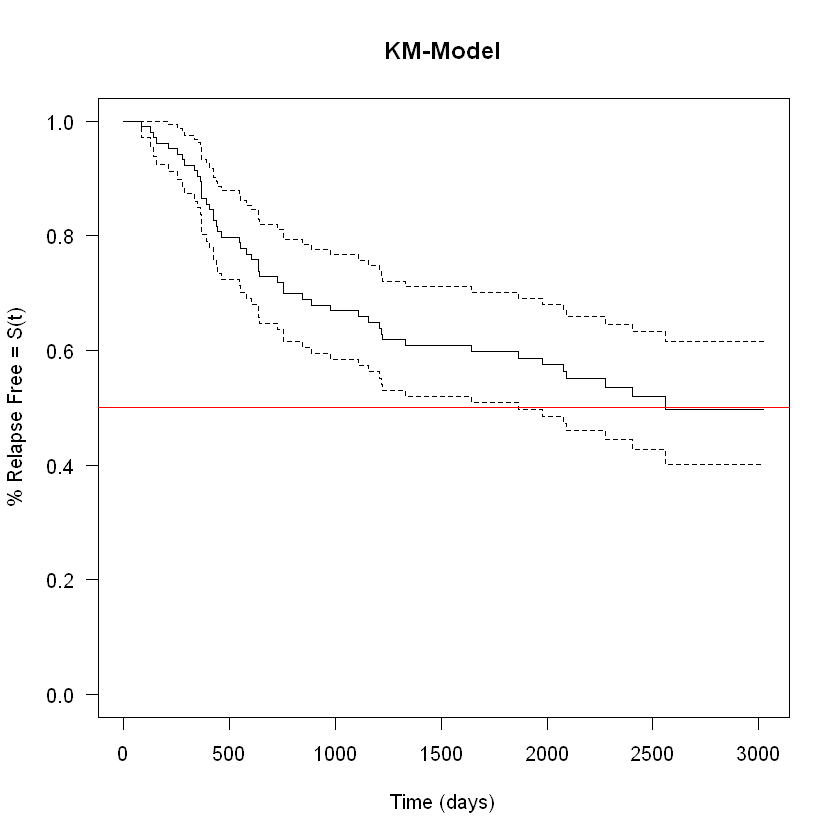

In [ ]:
# fit relapse free time & event kaplan meier
km_model <- survfit( Surv(clinical_model$relapse_free_time, clinical_model$relapse_free_event) ~ 1, type="kaplan-meier" )
km_model
summary(km_model)
plot(km_model, conf.int=T, xlab="Time (days)", ylab="% Relapse Free = S(t)", main="KM-Model", las=1)
abline(h=0.5, col="red", mark.time=TRUE)

[1] 56

,sample_id,tissue_type,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_time,overall_survival_event,overall_survival_time,age_group
,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>
GSM1045208,GSM1045208,breast cancer,74.03,2,0.6,1,1,0,3026,0,3026,1
GSM1045209,GSM1045209,breast cancer,67.26,2,5.0,1,1,1,755,1,755,1
GSM1045210,GSM1045210,breast cancer,53.35,1,3.5,1,0,0,3014,0,3014,0
GSM1045211,GSM1045211,breast cancer,43.72,3,1.5,1,1,1,406,1,1726,0
GSM1045212,GSM1045212,breast cancer,51.47,3,2.7,0,0,0,2225,0,2225,0
GSM1045213,GSM1045213,breast cancer,42.49,3,5.0,0,1,1,252,1,285,0


Call: survfit(formula = Surv(clinical_model$relapse_free_time, clinical_model$relapse_free_event) ~ 
    clinical_model$age_group, type = "kaplan-meier")

                            n events median 0.95LCL 0.95UCL
clinical_model$age_group=0 49     21     NA    1641      NA
clinical_model$age_group=1 55     27   2275    1216      NA

Call: survfit(formula = Surv(clinical_model$relapse_free_time, clinical_model$relapse_free_event) ~ 
    clinical_model$age_group, type = "kaplan-meier")

                clinical_model$age_group=0 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
   84     49       1    0.980  0.0202        0.941        1.000
  124     48       1    0.959  0.0283        0.905        1.000
  138     47       1    0.939  0.0342        0.874        1.000
  252     46       1    0.918  0.0391        0.845        0.998
  276     45       1    0.898  0.0432        0.817        0.987
  332     44       1    0.878  0.0468        0.790        0.974
  362     43       1    0.857  0.0500        0.765        0.961
  368     42       1    0.837  0.0528        0.739        0.947
  390     41       1    0.816  0.0553        0.715        0.932
  406     40       1    0.796  0.0576        0.691        0.917
  459     38       1    0.775  0.0597        0.666        0.901
  545     37       1    0.754  0.

Call:
survdiff(formula = Surv(clinical_model$relapse_free_time, clinical_model$relapse_free_event) ~ 
    clinical_model$age_group)

                            N Observed Expected (O-E)^2/E (O-E)^2/V
clinical_model$age_group=0 49       21     22.2    0.0603     0.112
clinical_model$age_group=1 55       27     25.8    0.0517     0.112

 Chisq= 0.1  on 1 degrees of freedom, p= 0.7 

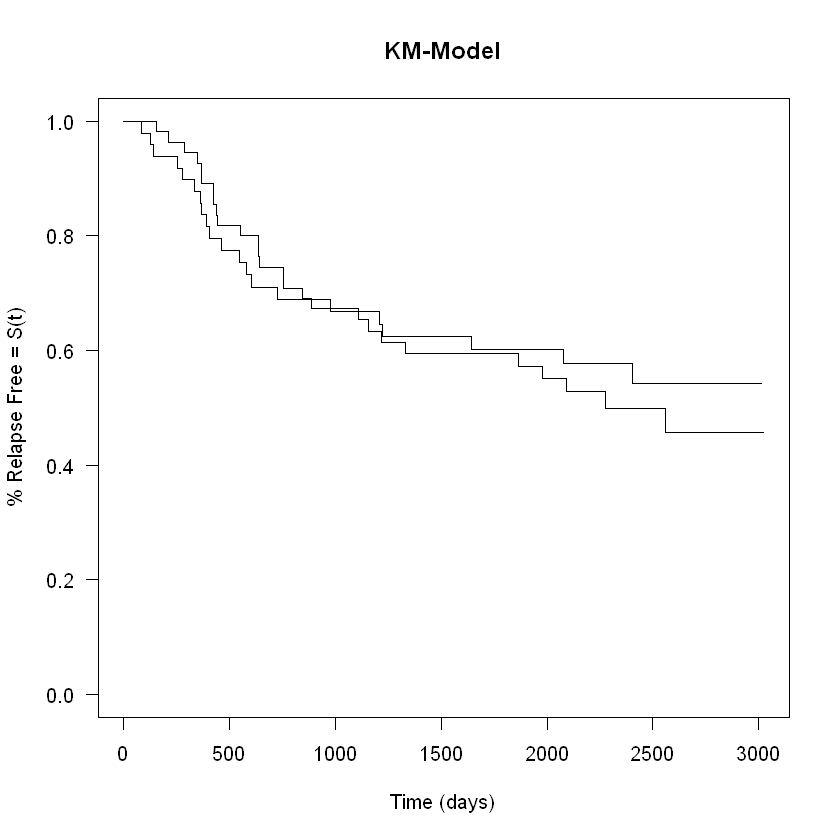

In [23]:
# find median age
median_age <- as.integer(median(clinical_model$patient_age))
median_age

# make age into a binary form
clinical_model$age_group <- ifelse(clinical_model$patient_age > 56, 1, 0)
head(clinical_model)

# fit relapse free time & event kaplan meier WITH AGE GROUP
km_model <- survfit(Surv(clinical_model$relapse_free_time, clinical_model$relapse_free_event)~clinical_model$age_group, type="kaplan-meier")
km_model
summary(km_model)
plot(km_model, conf.int=F, xlab="Time (days)", ylab="% Relapse Free = S(t)", main="KM-Model", las=1)

# survival difference between two age groups
survdiff(Surv(clinical_model$relapse_free_time, clinical_model$relapse_free_event)~clinical_model$age_group)

# Cox PH in R